# Fbxw7 Deletion Mutant Analysis using Ubicon

This notebook reproduces the prediction results for Fbxw7 deletion mutants:
- **Fbxw7_Ori**: Wild-type Fbxw7 (full-length, Q969H0)
- **Fbxw7_rm_F-box**: Deletion of F-box domain (residues 278-324)
- **Fbxw7_rm_N_terminal**: Deletion of N-terminal region (residues 1-151)

All predictions are made against c-Myc (P01106).

**Note: The following mutation data files are required in this directory:**
- `mutation_embeddings.pt` - Combined ESM-C embeddings (wild-type + mutants)
- `mutation_localization.csv` - Combined DeepLoc2 predictions (wild-type + mutants)
- `mutation_3di.json` - Combined Foldseek 3Di structures (wild-type + mutants)

If you want to prepare these files locally, follow the instructions in tutorial.ipynb. 

## Setup and Import Libraries

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

# Add Ubicon directory to path
ubicon_path = Path('..').resolve()
sys.path.insert(0, str(ubicon_path))

# Font settings for publication-quality figures
# Use default sans-serif fonts available on the system
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

print(f"Ubicon path: {ubicon_path}")
print(f"Working directory: {os.getcwd()}")

Ubicon path: /gs/bs/tga-asm/share_dir/Ubi/Ubicon
Working directory: /gs/bs/tga-asm/share_dir/Ubi/Ubicon/analysis


## 1. Load Required Data and Models

Load all necessary files for Ubicon prediction.

In [2]:
import torch
import json
import joblib
from catboost import CatBoostClassifier

# Path settings
model_path = "../models/final_catboost_model.cbm"
isotonic_model_path = "../models/isotonic_calibration_model.pkl"

# mutation data paths (in this directory)
mutation_embedding_path = "mutation_embeddings.pt"
mutation_location_path = "mutation_localization.csv"
mutation_3di_path = "mutation_3di.json"

print("Loading data...")

# Load mutation embeddings
embeddings_dict = torch.load(mutation_embedding_path, weights_only=False)
print(f"Loaded {len(embeddings_dict)} embeddings")

# Load mutation localization
localization_df = pd.read_csv(mutation_location_path)
localization_df.set_index('Protein_ID', inplace=True)
print(f"Loaded {len(localization_df)} localization entries")

# Load mutation 3Di
with open(mutation_3di_path, "r") as f:
    protein_3di_dict = json.load(f)
print(f"Loaded {len(protein_3di_dict)} 3Di structures")

# Load models
print("\nLoading models...")
model = CatBoostClassifier()
model.load_model(model_path)
ir_model = joblib.load(isotonic_model_path)
print("Models loaded successfully")

print("\n" + "="*60)
print("DATA LOADING COMPLETE")
print("="*60)
print(f"Available proteins: {sorted(embeddings_dict.keys())}")
print("="*60)

Loading data...
Loaded 4 embeddings
Loaded 4 localization entries
Loaded 4 3Di structures

Loading models...
Models loaded successfully

DATA LOADING COMPLETE
Available proteins: ['Fbxw7_rm_F-box', 'Fbxw7_rm_N_terminal', 'P01106', 'Q969H0']


In [3]:
protein_3di_dict

{'Q969H0': 'DLPPVLVPPDDDDDDDDDDDDDDPPVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVPPDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDYDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDPDDDDPPPDDPVVPPPDDDPQPDPPVDDDDPCPVVVVVVLVVDDPVVVVVVVVVVCVPDDPVVVVVVCVRVVVVVPDDPLVVDDLVVSLVVVLPDDLVVLVVLLVPDVVSVVSSQDQVSLVVVCVVVVNNDFADDPDPDDPDPDDDGHSSNLSVVQLVLLLCCVQDNDFDFWQWQFDPWLWAQQDWDDDDQWIWTFTQVQWIWIAGLVPSDTQDIQDDGPGGWREWDDDDQWIWTWGQSQWIFIAGSNVSDTPEIAHDGPGTQHYWDDDPQWIWTWGQVQKIWIAGRPVSDTQAIQHDGPGGWADWDDDPQWIWTFFQSQWIFIDGRNVSDGPDIQDDGPGGWHEWDDDPFWIWTWGQSQWIWIAGRPVSDTPDTQHDGDGGFQYWDADPQWIWTFFQSQKIWIARVVVSDGQEIQDDPPTDPGGWQEWDDDQFWIWTFWLLQWIWIAGPNPSYTSDTSTHDPCSVPFKGFNYWDDDSFKIKTFIAGNPHPGTTIITITGSRDDPD\n',
 'P01106': 'DDDDDDPPPPPPPPPPPPPDPPDPPDDDPPPVVVVPPDDDDDDPDDPCPCVVVVPDDPDDPDDDPDDDPDDDDDDDDDDDDDDDDDDDDDDDDDVVVVVVVVCCVVVDPPPPPDDPDDPPPPVVVVVVVPPPPPPPPPDPVVVVVVVVVVVVVVVPPPDDDDDDDDDDDDDPPPVCPVVVVVVVVPPDDDVVVVDPDPPDDPDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDPPPVDPPDPPP

## 2. Define Feature Preparation and Prediction Functions

In [4]:
def prepare_features_for_prediction(e3_id, sub_id, embeddings_dict, localization_df, protein_3di_dict):
    """Prepare feature vector for Ubicon prediction"""

    # 10 compartments
    compartments = [
        'Cytoplasm', 'Nucleus', 'Extracellular', 'Cell membrane', 'Mitochondrion',
        'Plastid', 'Endoplasmic reticulum', 'Lysosome/Vacuole', 'Golgi apparatus', 'Peroxisome'
    ]

    # Get ESM embeddings
    if e3_id in embeddings_dict:
        e3_emb = embeddings_dict[e3_id].numpy()
    else:
        print(f"Warning: {e3_id} not found in embeddings")
        sample_key = list(embeddings_dict.keys())[0]
        e3_emb = np.zeros_like(embeddings_dict[sample_key].numpy())

    if sub_id in embeddings_dict:
        sub_emb = embeddings_dict[sub_id].numpy()
    else:
        print(f"Warning: {sub_id} not found in embeddings")
        sample_key = list(embeddings_dict.keys())[0]
        sub_emb = np.zeros_like(embeddings_dict[sample_key].numpy())

    # Get 3Di data
    e3_3di = protein_3di_dict.get(e3_id, '')
    sub_3di = protein_3di_dict.get(sub_id, '')

    # Calculate 3Di features
    e3_3di_counts = np.zeros(21)
    for char in e3_3di:
        if char in "DVPLSQCARNHGKMIFYWETX":
            idx = "DVPLSQCARNHGKMIFYWETX".index(char) + 1
            e3_3di_counts[idx] += 1
    e3_3di_freq = e3_3di_counts / max(len(e3_3di), 1)

    sub_3di_counts = np.zeros(21)
    for char in sub_3di:
        if char in "DVPLSQCARNHGKMIFYWETX":
            idx = "DVPLSQCARNHGKMIFYWETX".index(char) + 1
            sub_3di_counts[idx] += 1
    sub_3di_freq = sub_3di_counts / max(len(sub_3di), 1)

    # Get localization features
    e3_compartment_features = np.zeros(len(compartments))
    sub_compartment_features = np.zeros(len(compartments))

    # E3 protein localization
    if e3_id in localization_df.index:
        for i, compartment in enumerate(compartments):
            if compartment in localization_df.columns:
                try:
                    score = localization_df.at[e3_id, compartment]
                    if isinstance(score, (int, float)):
                        e3_compartment_features[i] = score
                except:
                    pass

    # Substrate protein localization
    if sub_id in localization_df.index:
        for i, compartment in enumerate(compartments):
            if compartment in localization_df.columns:
                try:
                    score = localization_df.at[sub_id, compartment]
                    if isinstance(score, (int, float)):
                        sub_compartment_features[i] = score
                except:
                    pass

    # Concatenate all features
    feature_vector = np.concatenate([
        e3_emb, sub_emb, e3_3di_freq, sub_3di_freq,
        e3_compartment_features, sub_compartment_features
    ])

    return feature_vector

print("Feature preparation functions defined")

Feature preparation functions defined


## 3. Run Predictions for Fbxw7 Variants

Predict interaction scores for three Fbxw7 variants with c-Myc.

In [5]:
# Define test pairs (Fbxw7 variants with c-Myc only)
test_pairs = [
    {"e3_name": "Fbxw7_Ori", "substrate_name": "c-Myc"},
    {"e3_name": "Fbxw7_rm_F-box", "substrate_name": "c-Myc"},
    {"e3_name": "Fbxw7_rm_N_terminal", "substrate_name": "c-Myc"}
]

# Map variant names to actual IDs
id_mapping = {
    "Fbxw7_Ori": "Q969H0",
    "c-Myc": "P01106",
    "Fbxw7_rm_F-box": "Fbxw7_rm_F-box",
    "Fbxw7_rm_N_terminal": "Fbxw7_rm_N_terminal"
}

df_test = pd.DataFrame(test_pairs)
df_test['e3_uniprot_id'] = df_test['e3_name'].map(id_mapping)
df_test['substrate_uniprot_id'] = df_test['substrate_name'].map(id_mapping)

# Run predictions
print("Computing prediction scores...")
prediction_scores = []

for _, row in df_test.iterrows():
    e3_id = row['e3_uniprot_id']
    sub_id = row['substrate_uniprot_id']

    print(f"  Predicting: {row['e3_name']} ({e3_id}) - {row['substrate_name']} ({sub_id})")

    # Prepare features
    features = prepare_features_for_prediction(
        e3_id, sub_id, embeddings_dict, localization_df, protein_3di_dict
    )

    # Predict
    features_reshaped = features.reshape(1, -1)
    predicted_prob = model.predict_proba(features_reshaped)[0, 1]
    prediction_scores.append(predicted_prob)

# Add results to dataframe
df_test['substrate_prediction_score'] = prediction_scores

# Apply isotonic regression calibration
df_test['Ubicon Score'] = ir_model.predict(
    np.array(df_test['substrate_prediction_score']).reshape(-1, 1)
)

# Display results
print("\n" + "="*60)
print("PREDICTION RESULTS")
print("="*60)
print(df_test[['e3_name', 'substrate_name', 'substrate_prediction_score',
               'Ubicon Score']].to_string(index=False))
print("="*60)

# Store results for visualization
results = {}
for _, row in df_test.iterrows():
    results[row['e3_name']] = row['Ubicon Score']

print(f"\nResults stored: {results}")

Computing prediction scores...
  Predicting: Fbxw7_Ori (Q969H0) - c-Myc (P01106)
  Predicting: Fbxw7_rm_F-box (Fbxw7_rm_F-box) - c-Myc (P01106)
  Predicting: Fbxw7_rm_N_terminal (Fbxw7_rm_N_terminal) - c-Myc (P01106)

PREDICTION RESULTS
            e3_name substrate_name  substrate_prediction_score  Ubicon Score
          Fbxw7_Ori          c-Myc                    0.988149      0.878049
     Fbxw7_rm_F-box          c-Myc                    0.033727      0.088700
Fbxw7_rm_N_terminal          c-Myc                    0.561550      0.562874

Results stored: {'Fbxw7_Ori': 0.8780487804878049, 'Fbxw7_rm_F-box': 0.08869987849331713, 'Fbxw7_rm_N_terminal': 0.562874251497006}


TBB Warning: The number of workers is currently limited to 47. The request for 383 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.



## 4. Visualize Results

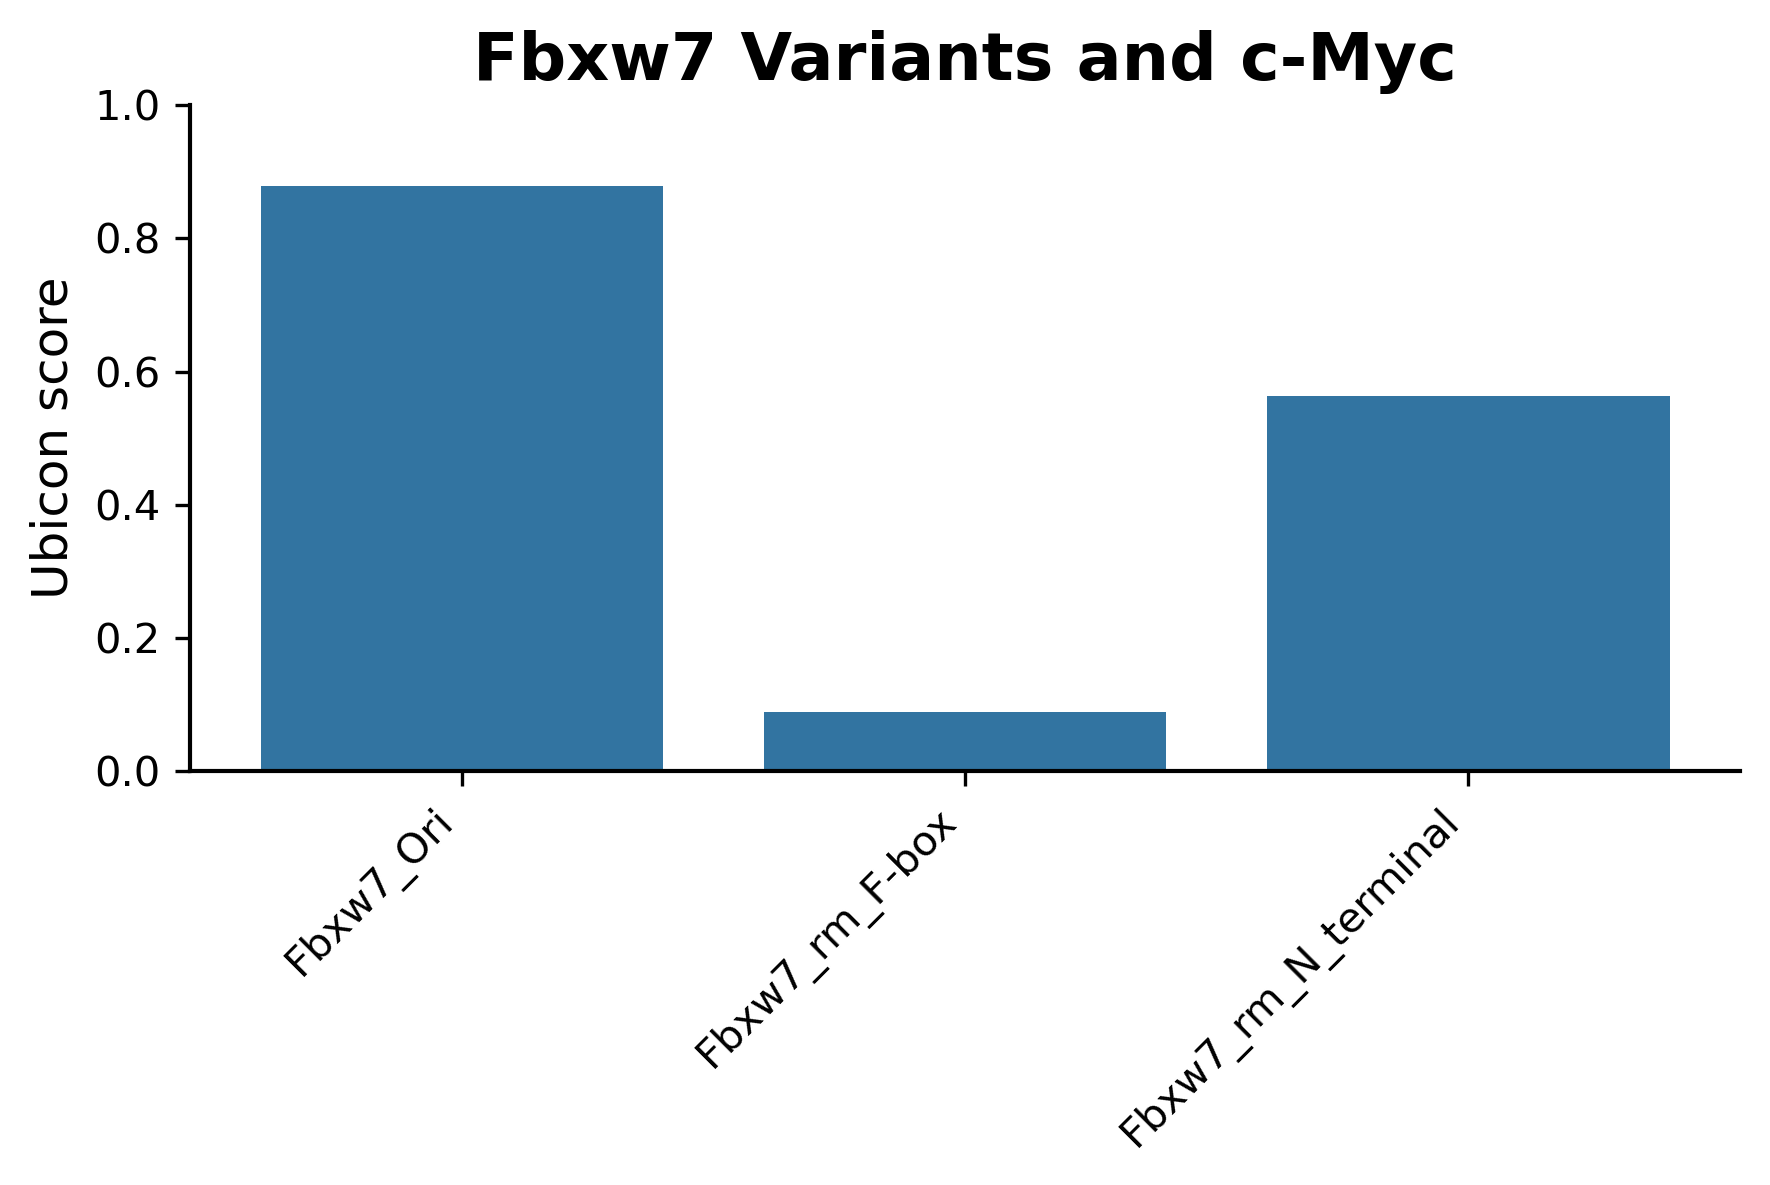


Visualization complete


In [6]:
plt.style.use('default')

# Prepare data for visualization
e3_names = ["Fbxw7_Ori", "Fbxw7_rm_F-box", "Fbxw7_rm_N_terminal"]
ir_scores_1 = [results[name] for name in e3_names]

# Create figure
fig = plt.figure(figsize=(6, 4.5))
fig.set_dpi(300)  # High resolution setting

width = 0.80

# Comparison of each Fbxw7 variant with c-Myc
ax = fig.add_subplot(111)
x = np.arange(len(e3_names))
bars = ax.bar(x, ir_scores_1, width, color='#3274A1', linewidth=0.5)

# Plot settings
ax.set_title('Fbxw7 Variants and c-Myc', fontsize=16, fontweight='bold')
ax.set_ylabel('Ubicon score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(e3_names, rotation=45, ha='right', fontsize=10)

# Remove grid lines
ax.grid(False)

# Frame settings - hide right and top frames
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Set color and width for remaining frames
for spine_name, spine in ax.spines.items():
    if spine_name in ['left', 'bottom']:
        spine.set_linewidth(1)

# Adjust margins
plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# Display the graph
plt.show()

print("\nVisualization complete")

## 5. SHAP Analysis - Feature Importance

Analyze which features contribute most to the predictions for each Fbxw7 variant.

## 5. SHAP Analysis - Feature Importance

Analyze which features contribute most to the predictions for each Fbxw7 variant.

In [ ]:
import shap
import warnings
warnings.filterwarnings('ignore')

print("Running SHAP analysis...")

# Prepare features (self-pairs)
e3_samples = ['Q969H0', 'Fbxw7_rm_F-box', 'Fbxw7_rm_N_terminal']
compartments = ['Cytoplasm', 'Nucleus', 'Extracellular', 'Cell membrane', 'Mitochondrion',
               'Plastid', 'Endoplasmic reticulum', 'Lysosome/Vacuole', 'Golgi apparatus', 'Peroxisome']
alphabet = "DVPLSQCARNHGKMIFYWETX"

def calc_3di_freq(seq_3di):
    """Calculate 3Di frequency vector"""
    counts = np.zeros(21)
    for char in seq_3di:
        if char in alphabet:
            idx = alphabet.index(char) + 1
            if idx < 21:
                counts[idx] += 1
    return counts / max(len(seq_3di), 1)

features_list = []
for e3_sample in e3_samples:
    # E3 features
    e3_emb = embeddings_dict[e3_sample].numpy()
    e3_loc = localization_df.loc[e3_sample][compartments].values.astype(float)
    e3_3di = calc_3di_freq(protein_3di_dict[e3_sample])
    
    # Substrate features (self-pair)
    sub_emb = e3_emb.copy()
    sub_loc = e3_loc.copy()
    sub_3di = e3_3di.copy()
    
    # Concatenate
    combined = np.concatenate([e3_emb, sub_emb, e3_3di, sub_3di, e3_loc, sub_loc])
    features_list.append(combined)

# Feature names
feature_names = (
    [f'E3_ESM_{i}' for i in range(960)] +
    [f'Sub_ESM_{i}' for i in range(960)] +
    [f'E3_3Di_{c}' for c in alphabet] +
    [f'Sub_3Di_{c}' for c in alphabet] +
    [f'E3_Loc_{c}' for c in compartments] +
    [f'Sub_Loc_{c}' for c in compartments]
)

features_df = pd.DataFrame(features_list, columns=feature_names, index=e3_samples)

# Calculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer(features_df)

print(f"SHAP values computed: {shap_values.values.shape}")

In [ ]:
# Calculate feature category contributions
category_contrib = []
for idx, sample in enumerate(features_df.index):
    sample_shap = shap_values.values[idx]
    
    e3_esm_contrib = np.sum(np.abs(sample_shap[:960]))
    sub_esm_contrib = np.sum(np.abs(sample_shap[960:1920]))
    e3_3di_contrib = np.sum(np.abs(sample_shap[1920:1941]))
    sub_3di_contrib = np.sum(np.abs(sample_shap[1941:1962]))
    e3_loc_contrib = np.sum(np.abs(sample_shap[1962:1972]))
    sub_loc_contrib = np.sum(np.abs(sample_shap[1972:1982]))
    
    total = (e3_esm_contrib + sub_esm_contrib + e3_3di_contrib +
            sub_3di_contrib + e3_loc_contrib + sub_loc_contrib)
    
    category_contrib.append({
        'Sample': sample,
        'E3_ESM': e3_esm_contrib,
        'Sub_ESM': sub_esm_contrib,
        'E3_3Di': e3_3di_contrib,
        'Sub_3Di': sub_3di_contrib,
        'E3_Location': e3_loc_contrib,
        'Sub_Location': sub_loc_contrib,
        'E3_ESM_ratio': e3_esm_contrib / total * 100,
        'Sub_ESM_ratio': sub_esm_contrib / total * 100,
        'E3_3Di_ratio': e3_3di_contrib / total * 100,
        'Sub_3Di_ratio': sub_3di_contrib / total * 100,
        'E3_Loc_ratio': e3_loc_contrib / total * 100,
        'Sub_Loc_ratio': sub_loc_contrib / total * 100
    })

category_df = pd.DataFrame(category_contrib)

print("
Feature Category Contribution (%):")
print("="*60)
for _, row in category_df.iterrows():
    print(f"
{row['Sample']}:")
    print(f"  E3 ESM: {row['E3_ESM_ratio']:.2f}%")
    print(f"  Sub ESM: {row['Sub_ESM_ratio']:.2f}%")
    print(f"  E3 3Di: {row['E3_3Di_ratio']:.2f}%")
    print(f"  Sub 3Di: {row['Sub_3Di_ratio']:.2f}%")
    print(f"  E3 Location: {row['E3_Loc_ratio']:.2f}%")
    print(f"  Sub Location: {row['Sub_Loc_ratio']:.2f}%")
print("="*60)

In [ ]:
# Visualize category contributions
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(category_df))
width = 0.13

ax.bar(x - 2.5*width, category_df['E3_ESM_ratio'], width, label='E3 ESM', alpha=0.8, color='#1f77b4')
ax.bar(x - 1.5*width, category_df['Sub_ESM_ratio'], width, label='Sub ESM', alpha=0.8, color='#ff7f0e')
ax.bar(x - 0.5*width, category_df['E3_3Di_ratio'], width, label='E3 3Di', alpha=0.8, color='#2ca02c')
ax.bar(x + 0.5*width, category_df['Sub_3Di_ratio'], width, label='Sub 3Di', alpha=0.8, color='#d62728')
ax.bar(x + 1.5*width, category_df['E3_Loc_ratio'], width, label='E3 Location', alpha=0.8, color='#9467bd')
ax.bar(x + 2.5*width, category_df['Sub_Loc_ratio'], width, label='Sub Location', alpha=0.8, color='#8c564b')

ax.set_xlabel('Fbxw7 Variant', fontsize=12)
ax.set_ylabel('Contribution Ratio (%)', fontsize=12)
ax.set_title('Feature Category Contribution by SHAP', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['WT', 'rm_F-box', 'rm_N_terminal'], rotation=0)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Frame settings
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

print("
SHAP category contribution plot displayed")

In [ ]:
# Display Top 10 important features
print("
Top 10 Important Features by SHAP (for each variant):")
print("="*60)

for idx, sample in enumerate(features_df.index):
    sample_shap = shap_values.values[idx]
    abs_shap = np.abs(sample_shap)
    top_indices = np.argsort(abs_shap)[-10:][::-1]
    
    print(f"
{sample}:")
    for i, feat_idx in enumerate(top_indices, 1):
        feat_name = features_df.columns[feat_idx]
        shap_val = sample_shap[feat_idx]
        print(f"  {i}. {feat_name}: SHAP={shap_val:+.6f}")
print("="*60)

In [ ]:
# SHAP Summary Plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values.values, features_df, max_display=15, show=False)
plt.title('SHAP Feature Importance - Top 15 Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("
SHAP summary plot displayed")